In [1]:
from __future__ import annotations

from offline_opt import StationSpec, compute_offline_bound
from toy_demo.runner import run_toy_episode
from toy_demo.scenario import ToyEVSpec, ToyStationSpec, build_evs

In [2]:
STATION = ToyStationSpec(n_piles=2, n_dispensers=2, n_modules=5, p_module=25.0)

EV_SPECS = [
    ToyEVSpec(id=0, arrival_time=0.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),
    ToyEVSpec(id=1, arrival_time=2.0, battery_kwh=100.0, s_i=0.15, s_f=0.85),
    ToyEVSpec(id=2, arrival_time=8.0, battery_kwh=50.0, s_i=0.25, s_f=0.75),
    ToyEVSpec(id=3, arrival_time=12.0, battery_kwh=150.0, s_i=0.10, s_f=0.80),
    ToyEVSpec(id=4, arrival_time=10.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),
#    ToyEVSpec(id=5, arrival_time=0.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),
#    ToyEVSpec(id=6, arrival_time=0.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),
#    ToyEVSpec(id=7, arrival_time=0.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),
#    ToyEVSpec(id=8, arrival_time=0.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),

]
offline_station = StationSpec(
    n_piles=STATION.n_piles,
    n_dispensers=STATION.n_dispensers,
    n_modules=STATION.n_modules,
    p_module=STATION.p_module,
)

In [10]:
from offline_opt import (
    build_offline_model,
    solve_offline_model,
    extract_solution,
    taper_time_constant,
    vehicles_from_evs,
    default_horizon_minutes,
)

# Built via the lower-level calls (rather than compute_offline_bound) so we
# keep offline_model around -- the plotting functions below read variable
# values (.X) directly off it, which the OfflineSolution summary doesn't expose.
vehicles = vehicles_from_evs(build_evs(EV_SPECS))
tau = taper_time_constant()
horizon = default_horizon_minutes(vehicles, offline_station)

offline_model = build_offline_model(
    vehicles, offline_station, delta=1, horizon_minutes=horizon, tau=tau,
    tie_break=False,
)
solve_offline_model(offline_model, mip_gap=1e-4, time_limit=300)
solution = extract_solution(offline_model)

In [11]:
solution.mip_gap

0.0

In [12]:
print(f"=== Offline MILP (status={solution.status}, gap={solution.mip_gap:.2%}) ===")
print(solution.per_vehicle.to_string(index=False))
print(f"  total sojourn = {solution.total_sojourn:.2f} min\n")


=== Offline MILP (status=OPTIMAL, gap=0.00%) ===
 vehicle_id  arrival  pile  service_start  departure  sojourn  energy_kwh  energy_required_kwh
          0      0.0     1              0       26.0     26.0        30.0                 30.0
          1      2.0     0              2       54.0     52.0        70.0                 70.0
          2      8.0     0              8       28.0     20.0        25.0                 25.0
          3     12.0     1             26       83.0     71.0       105.0                105.0
          4     10.0     1             10       40.0     30.0        30.0                 30.0
  total sojourn = 199.00 min



In [13]:
from offline_opt import plot_vehicle_power_and_modules
import matplotlib.pyplot as plt

# One figure per vehicle id: power drawn each slot (bars, straight off the
# solved MILP's p[j,k]), the reconstructed BMS max request (dashed, left
# axis), and modules assigned (dashed step, right axis, sum_m b[j,m,k]).
figs = plot_vehicle_power_and_modules(
    offline_model,
    vehicle_ids=[0, 1, 2, 3, 4],   # <- enter any subset of vehicle ids here
    show_bms_request=True,
    show_modules=True,
    bar_width=0.9,
)


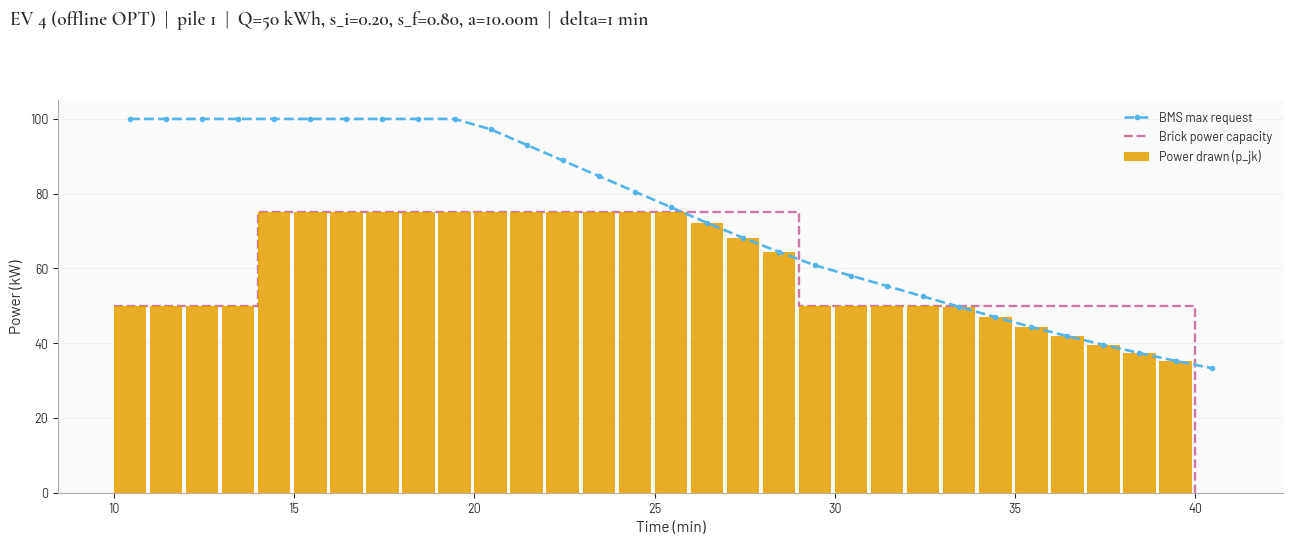

In [14]:
figs[4]

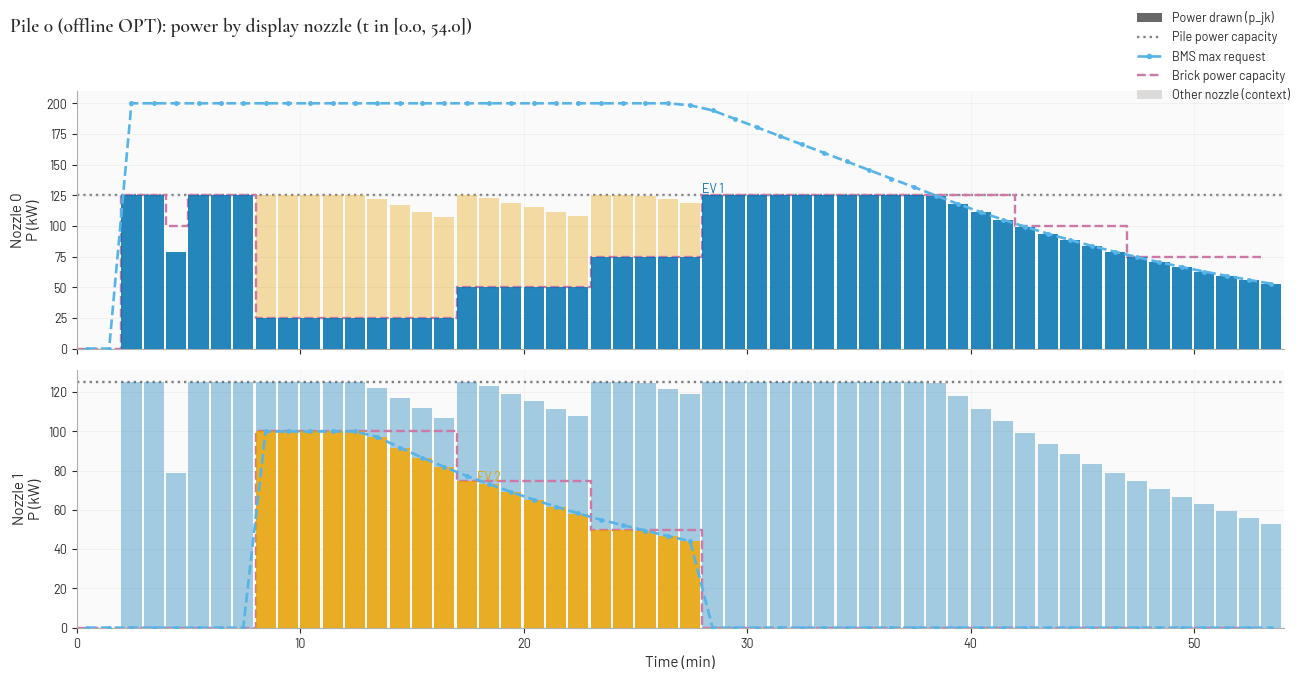

In [17]:
from offline_opt import plot_pile_power_and_modules
import matplotlib.pyplot as plt

# One figure per pile id: one subplot per *display* dispenser (the MILP only
# decides pile assignment + dispenser count per slot, not dispenser identity --
# see offline_opt/visualization.py's module docstring for how dispensers are
# assigned for display). Each subplot bars its occupant's power drawn per
# slot, BMS max request (dashed), and modules assigned (dashed, right axis).
# Call once per pile id you want to see.
fig = plot_pile_power_and_modules(
    offline_model,
    pile_id=0,                    # <- enter a pile id here
    t_start=None,                  # <- enter a time-window subset (None -> actual activity on this pile)
    t_end=None,
    stack_other_dispensers=True,     # toggle: stack other dispensers' power on top
    other_alpha=0.35,             #         (same pile, low alpha, for context)
    show_bms_request=True,
    show_modules=True,
    bar_width=0.9,
    show_ev_ids=True,
    show_pile_capacity=True
)
fig

In [7]:
solution.per_vehicle

,vehicle_id,arrival,pile,service_start,departure,sojourn,energy_kwh,energy_required_kwh
0,0,0.0,0,0,27.0,27.0,30.0,30.0
1,1,2.0,1,2,57.0,55.0,70.0,70.0
2,2,8.0,0,8,33.0,25.0,25.0,25.0
3,3,12.0,0,27,80.0,68.0,105.0,105.0
4,4,10.0,1,10,36.0,26.0,30.0,30.0


In [29]:
solution.per_vehicle

,vehicle_id,arrival,pile,service_start,departure,sojourn,energy_kwh,energy_required_kwh
0,0,0.0,1,0,26.0,26.0,30.0,30.0
1,1,2.0,0,2,54.0,52.0,70.0,70.0
2,2,8.0,0,8,28.0,20.0,25.0,25.0
3,3,12.0,1,26,83.0,71.0,105.0,105.0
4,4,10.0,1,10,40.0,30.0,30.0,30.0
